In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

In [4]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [5]:
if "daily_return" not in nav.columns:

    nav["daily_return"] = (
        nav.groupby("amfi_code")["nav"]
        .pct_change()
    )

In [6]:
returns = nav.dropna(
    subset=["daily_return"]
)

In [7]:
risk_report = []

In [10]:
for fund, group in returns.groupby("amfi_code"):
    daily_returns = group["daily_return"]

In [11]:
var_95 = np.percentile(
    daily_returns,
    5
)

In [12]:
cvar_95 = daily_returns[
    daily_returns <= var_95
].mean()

In [13]:
risk_report.append({
    "amfi_code": fund,
    "VaR_95": var_95,
    "CVaR_95": cvar_95
})

In [14]:
risk_report = pd.DataFrame(risk_report)

In [15]:
risk_report.head()

,amfi_code,VaR_95,CVaR_95
0,149324,-0.023483,-0.031036


In [16]:
risk_report.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

print("VaR & CVaR report saved successfully!")

VaR & CVaR report saved successfully!


rolling_sharpe_chart

In [17]:
top5_funds = (
    returns["amfi_code"]
    .drop_duplicates()
    .head(5)
    .tolist()
)

top5_funds

[100016, 100025, 100033, 101206, 101207]

In [18]:
plt.figure(figsize=(14,7))

<Figure size 1400x700 with 0 Axes>

<Figure size 1400x700 with 0 Axes>

In [19]:
for fund in top5_funds:

    fund_data = (
        returns[
            returns["amfi_code"] == fund
        ]
        .copy()
    )

In [20]:
fund_data["rolling_mean"] = (
    fund_data["daily_return"]
    .rolling(90)
    .mean()
)

In [22]:
fund_data["rolling_std"] = (
    fund_data["daily_return"]
    .rolling(90)
    .std()
)

In [23]:
fund_data["rolling_sharpe"] = (
    fund_data["rolling_mean"]
    /
    fund_data["rolling_std"]
) * np.sqrt(252)

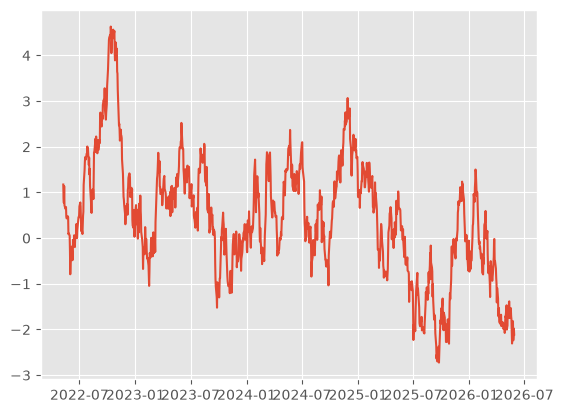

In [24]:
plt.plot(
    fund_data["date"],
    fund_data["rolling_sharpe"],
    label=str(fund)
)

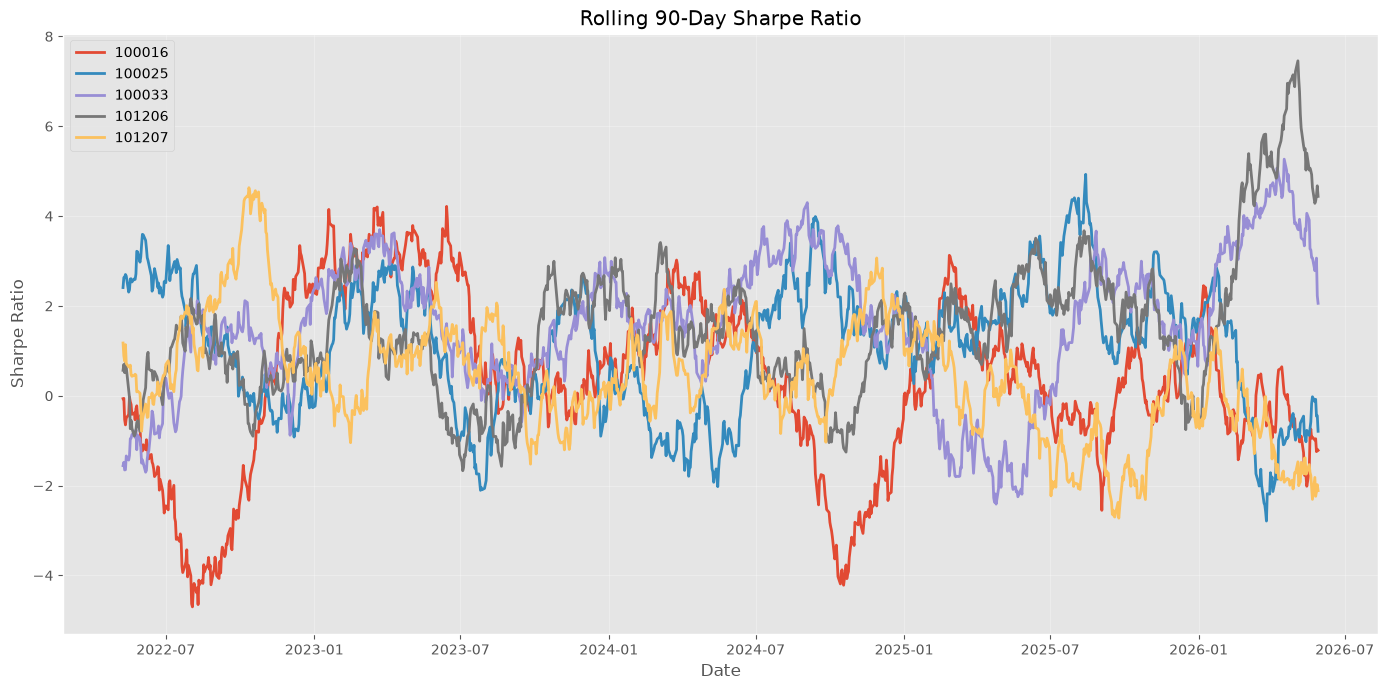

In [37]:
plt.figure(figsize=(14,7))

for fund in top5_funds:

    fund_data = returns[returns["amfi_code"] == fund].copy()

    fund_data = fund_data.sort_values("date")

    fund_data["rolling_mean"] = (
        fund_data["daily_return"]
        .rolling(window=90)
        .mean()
    )

    fund_data["rolling_std"] = (
        fund_data["daily_return"]
        .rolling(window=90)
        .std()
    )

    fund_data["rolling_sharpe"] = (
        fund_data["rolling_mean"] /
        fund_data["rolling_std"]
    ) * np.sqrt(252)

    # Remove NaN values before plotting
    plot_data = fund_data.dropna(subset=["rolling_sharpe"])

    plt.plot(
        plot_data["date"],
        plot_data["rolling_sharpe"],
        linewidth=2,
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

investor_cohort_report

In [40]:
transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [41]:
first_transaction = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction.head()

,investor_id,transaction_date
0,INV000001,2024-11-04
1,INV000002,2024-03-29
2,INV000003,2024-07-16
3,INV000004,2024-03-16
4,INV000005,2024-04-27


In [42]:
first_transaction["cohort_year"] = (
    first_transaction["transaction_date"]
    .dt.year
)

first_transaction.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [43]:
transactions = transactions.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [44]:
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
]

avg_sip = (
    sip_transactions
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount")
)

avg_sip

,cohort_year,avg_sip_amount


In [45]:
total_invested = (
    transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested")
)

total_invested

,cohort_year,total_invested
0,2024,3491125187
1,2025,30455243


In [46]:
top_fund = (
    transactions
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="num_transactions")
)

In [47]:
top_fund = (
    top_fund
    .sort_values(
        ["cohort_year", "num_transactions"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

top_fund

,cohort_year,amfi_code,num_transactions
35,2024,148568,874
62,2025,119599,12


In [48]:
top_fund = top_fund.rename(
    columns={
        "amfi_code": "top_fund"
    }
)

top_fund

,cohort_year,top_fund,num_transactions
35,2024,148568,874
62,2025,119599,12


In [49]:
cohort_report = (
    avg_sip
    .merge(
        total_invested,
        on="cohort_year"
    )
    .merge(
        top_fund[
            ["cohort_year", "top_fund"]
        ],
        on="cohort_year"
    )
)

cohort_report

,cohort_year,avg_sip_amount,total_invested,top_fund


In [50]:
cohort_report.to_csv(
    "../data/processed/investor_cohort_report.csv",
    index=False
)

print("Investor Cohort Report saved successfully!")

Investor Cohort Report saved successfully!


sip analysyis(cont)

In [57]:
sip_data = transactions[
    transactions["transaction_type"] == "Sip"
].copy()

sip_data.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,Sip,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,Sip,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [58]:
sip_data = sip_data.sort_values(
    ["investor_id", "transaction_date"]
)

In [59]:
sip_data["gap_days"] = (
    sip_data
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_data.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,Sip,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,Sip,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0
12652,INV000003,2024-07-16,101207,Sip,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN
27622,INV000003,2025-03-11,149322,Sip,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,238.0
4773,INV000004,2024-03-16,101208,Sip,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,Sip,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,Sip,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0


In [60]:
sip_count = (
    sip_data
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

sip_count.head()

,investor_id,sip_count
0,INV000001,2
1,INV000002,3
2,INV000003,2
3,INV000004,6
4,INV000005,3


In [61]:
eligible_investors = sip_count[
    sip_count["sip_count"] >= 6
]

eligible_investors.head()

,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [4]:
import pandas as pd
import numpy as np

transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [5]:
sip_data = transactions[
    transactions["transaction_type"] == "Sip"
].copy()

In [8]:
sip_count = (
    sip_data.groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

sip_count.head()

,investor_id,sip_count
0,INV000001,2
1,INV000002,3
2,INV000003,2
3,INV000004,6
4,INV000005,3


In [9]:
eligible_investors = sip_count[
    sip_count["sip_count"] >= 6
]

eligible_investors.head()

,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [10]:
sip_analysis = sip_data.merge(
    eligible_investors,
    on="investor_id",
    how="inner"
)

sip_analysis.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,sip_count
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,7
1,INV001497,2024-01-01,101208,Sip,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,9
2,INV000786,2024-01-01,101208,Sip,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,9
3,INV003670,2024-01-01,119120,Sip,10672,Punjab,Chandigarh,T30,36-45,Male,38.4,Net Banking,Verified,8
4,INV001023,2024-01-01,118636,Sip,4865,Gujarat,Ahmedabad,T30,36-45,Male,27.1,Net Banking,Verified,8


In [12]:
print(sip_data.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


In [13]:
sip_data = sip_data.sort_values(
    ["investor_id", "transaction_date"]
)

sip_data["gap_days"] = (
    sip_data.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

In [14]:
sip_data.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status', 'gap_days'],
      dtype='str')

In [16]:
sip_count = (
    sip_data.groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible_investors = sip_count[
    sip_count["sip_count"] >= 6
]

In [17]:
sip_analysis = sip_data.merge(
    eligible_investors,
    on="investor_id",
    how="inner"
)

sip_analysis.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,gap_days,sip_count
0,INV000004,2024-03-16,101208,Sip,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,NaN,6
1,INV000004,2024-04-11,119095,Sip,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,26.0,6
2,INV000004,2024-05-09,120844,Sip,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,28.0,6
3,INV000004,2024-07-07,148569,Sip,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,59.0,6
4,INV000004,2025-03-29,149324,Sip,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,265.0,6


In [18]:
avg_gap = (
    sip_analysis
    .groupby("investor_id")["gap_days"]
    .mean()
    .reset_index(name="avg_gap_days")
)

avg_gap.head()

,investor_id,avg_gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [19]:
avg_gap["status"] = np.where(
    avg_gap["avg_gap_days"] > 35,
    "At Risk",
    "Regular"
)

avg_gap.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [20]:
avg_gap["status"].value_counts()

status
At Risk    1332
Regular      30
Name: count, dtype: int64

In [21]:
avg_gap.to_csv(
    "../data/processed/sip_continuity_report.csv",
    index=False
)

print("SIP Continuity Report saved successfully!")

SIP Continuity Report saved successfully!


sector hhi analytics

In [1]:
import pandas as pd

holdings = pd.read_csv(
    "../data/processed/09_portfolio_holdings_clean.csv"
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [ ]:

holdings["weight_decimal"] = holdings["weight_pct"] / 100

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,weight_decimal
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,0.1385
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,0.1119
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,0.0990
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,0.0476
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,0.1025


In [ ]:

holdings["weight_squared"] = holdings["weight_decimal"] ** 2

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,weight_decimal,weight_squared
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,0.1385,0.019182
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,0.1119,0.012522
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,0.0990,0.009801
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,0.0476,0.002266
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,0.1025,0.010506


In [ ]:

hhi = (
    holdings
    .groupby("amfi_code")["weight_squared"]
    .sum()
    .reset_index(name="HHI")
)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [5]:
fund_master = pd.read_csv(
    "../data/processed/01_fund_master_clean.csv"
)

hhi = hhi.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "category",
            "fund_house"
        ]
    ],
    on="amfi_code",
    how="left"
)

hhi.head()

,amfi_code,HHI,scheme_name,category,fund_house
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Equity,HDFC Mutual Fund
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,HDFC Mutual Fund
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Equity,Aditya Birla Sun Life MF
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity,Aditya Birla Sun Life MF
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity,UTI Mutual Fund


In [6]:
hhi = hhi.sort_values(
    "HHI",
    ascending=False
)

hhi.head(10)

,amfi_code,HHI,scheme_name,category,fund_house
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity,Axis Mutual Fund
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity,Aditya Birla Sun Life MF
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity,SBI Mutual Fund
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity,UTI Mutual Fund
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity,Nippon India MF
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity,Mirae Asset MF
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Equity,ICICI Prudential MF
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Equity,ICICI Prudential MF
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity,HDFC Mutual Fund
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Equity,Kotak Mahindra MF


In [7]:
hhi.to_csv(
    "../data/processed/sector_hhi_report.csv",
    index=False
)

print("Sector HHI Report Created Successfully!")

Sector HHI Report Created Successfully!


Advanced Analytics 

1. Historical Risk Analysis
The Historical VaR and CVaR analysis identified the mutual funds with the highest downside risk. Funds with larger negative VaR values are more vulnerable to adverse market conditions, while higher CVaR values indicate greater expected losses during extreme market events.



 2. Rolling Sharpe Ratio Performance
The 90-day Rolling Sharpe Ratio showed that fund performance varies significantly over time. Some funds consistently maintained positive risk-adjusted returns, while others experienced periods of declining Sharpe ratios during volatile market conditions.



 3. Investor Behaviour Analysis
Investor cohort analysis revealed differences in investment behaviour across different entry years. Certain cohorts invested larger average SIP amounts and displayed stronger preferences for specific mutual fund categories.



 4. SIP Continuity Analysis
Most investors maintained regular SIP contributions, while a smaller group exhibited average payment gaps exceeding 35 days. These investors were classified as "At Risk" and may require targeted retention strategies.



 5. Portfolio Concentration Analysis
The Herfindahl-Hirschman Index (HHI) highlighted differences in portfolio diversification across mutual funds. Funds with higher HHI values were more concentrated in a few holdings, whereas lower HHI values indicated better diversification and lower concentration risk.